In [3]:
# 시각화 라이브러리
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 처리
import pandas as pd
import numpy as np

# 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")


# 상위 5개 출력
print(df.head())

# df.to_excel("펭귄.xlsx")

# species → 펭귄 종류 (목표 확인용)
# island → 서식 섬
# bill_length_mm → 부리 길이
# bill_depth_mm → 부리 깊이
# flipper_length_mm → 날개 길이
# body_mass_g → 몸무게
# sex → 성별


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [5]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [ ]:
# 결측치 제거
# 수치형만 보기 위해 제거해 버림
df = df.dropna()

df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


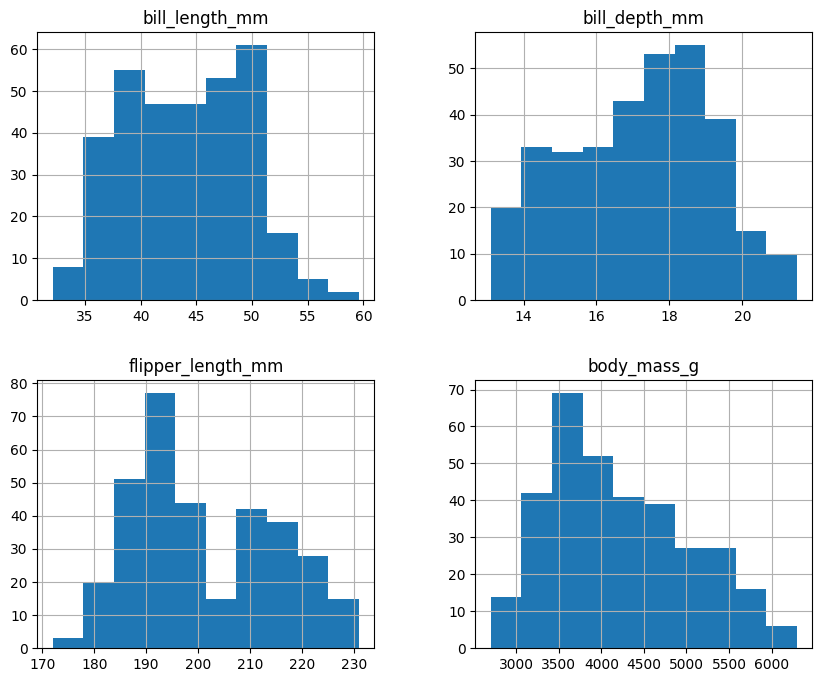

In [8]:

# 수치 컬럼만 선택
num_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# 히스토그램
df[num_cols].hist(
    figsize=(10,8)
)

plt.show()


                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


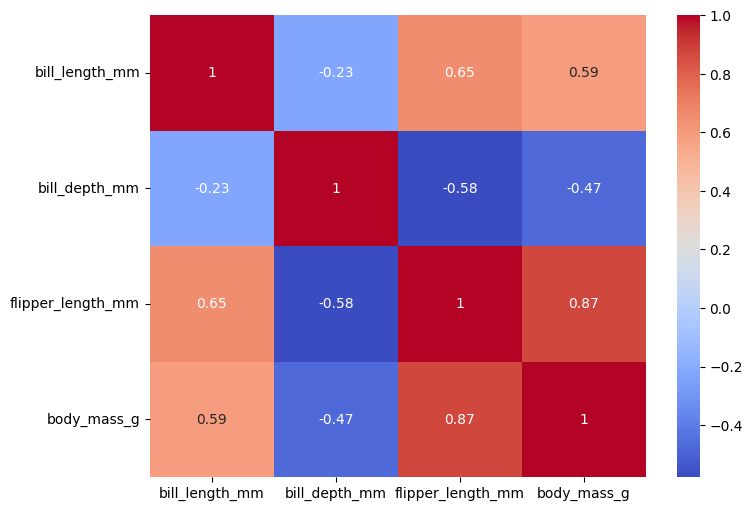

In [11]:
# 상관계수 계산
corr = df[num_cols].corr()

print(corr)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()


In [13]:
# PCA
from sklearn.preprocessing import StandardScaler

# 입력 데이터 선택
X = df[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])



[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 [-1.33556603  1.0858774  -0.56928439 -0.94160639]
 [-0.85941488  1.74702554 -0.78365118 -0.69285199]]


In [14]:
# PCA 수행
from sklearn.decomposition import PCA

# 2차원 축소
pca = PCA(n_components=2)
# PCA 적용
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:5])

[[-1.85359302  0.03206938]
 [-1.31625406 -0.44352677]
 [-1.37660509 -0.16123048]
 [-1.88528838 -0.01235124]
 [-1.91998074  0.81759813]]


In [ ]:
print(pca.explained_variance_ratio_)
# 설명력은 89% (두개를 더한값)


[0.68633893 0.19452929]


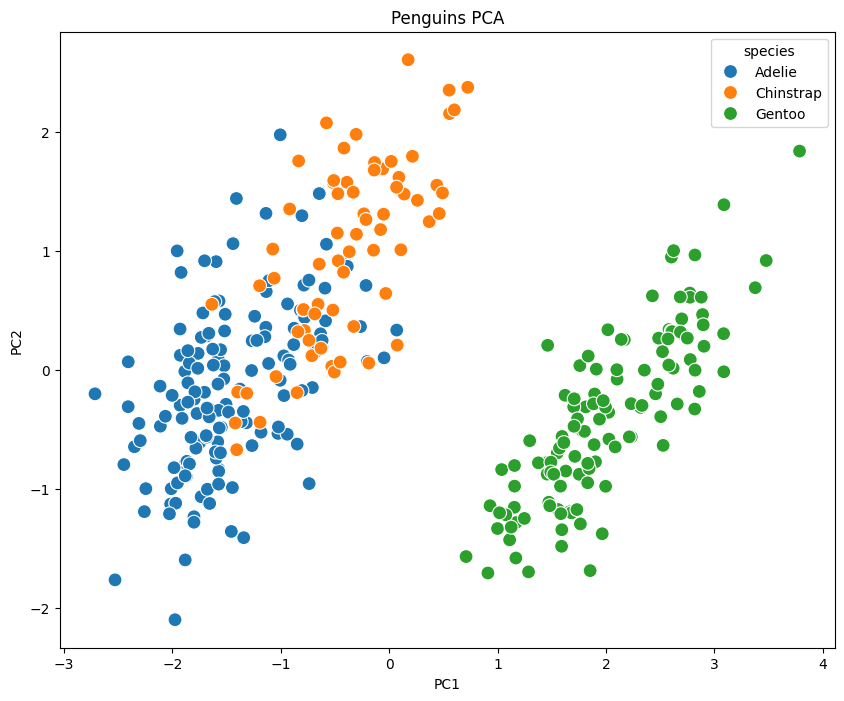

In [17]:
# PCA 결과 시각화

# 데이터프레임 생성
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)


# 종 정보 추가
pca_df["species"] = df["species"].values


# 그래프
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=100
)

plt.title("Penguins PCA")

plt.show()


In [22]:
print(pca.components_)

loading = pd.DataFrame(
    pca.components_,
    columns=num_cols,
    index=["PC1","PC2"]
)

print(loading)

# pc1 => 몸무게 + 날개길이
# pc2 => 부리

[[ 0.45375317 -0.39904723  0.576825    0.54967471]
 [ 0.6001949   0.79616951  0.00578817  0.07646366]]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
PC1        0.453753      -0.399047           0.576825     0.549675
PC2        0.600195       0.796170           0.005788     0.076464


In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [26]:

y = df['species']
X = df.drop(columns=['species'])

# 4. 더미변수 처리 (문자 → 숫자)
X = pd.get_dummies(X, drop_first=True)

# 5. train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. 스케일링 (PCA 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 8. 로지스틱 회귀
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)

# 9. 예측
y_pred = model.predict(X_test_pca)

# 10. 평가
print("accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 0.8955223880597015
              precision    recall  f1-score   support

      Adelie       0.83      0.97      0.90        31
   Chinstrap       0.88      0.54      0.67        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.90        67
   macro avg       0.90      0.84      0.85        67
weighted avg       0.90      0.90      0.89        67



In [31]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# =========================
# 1. 데이터 로드
# =========================
df = sns.load_dataset("penguins")

# 결측 제거
df = df.dropna()

# 타겟
y = df["species"]

# feature
X = df.drop(columns=["species"])

# 더미변수 처리 (범주형 → 숫자)
X = pd.get_dummies(X, drop_first=True)

# =========================
# 2. train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. 스케일링 (PCA 필수)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 4. (1) PCA 미적용 로지스틱 회귀
# =========================================================
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_scaled, y_train)

pred1 = model1.predict(X_test_scaled)

acc1 = accuracy_score(y_test, pred1)

# =========================================================
# 5. (2) PCA 적용 후 로지스틱 회귀
# =========================================================

# PCA (2차원 축소)
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_pca, y_train)

pred2 = model2.predict(X_test_pca)

acc2 = accuracy_score(y_test, pred2)

# =========================
# 6. 결과 출력
# =========================
print("PCA 미적용 정확도:", acc1)
print("PCA 적용 정확도:", acc2)

PCA 미적용 정확도: 1.0
PCA 적용 정확도: 0.8955223880597015


In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

np.random.seed(42)

# 정상 거래 (300건)
normal = np.random.normal(
    loc=[50, 10],
    scale=[10, 3],
    size=(300, 2)
)

# 이상 거래 (20건)
fraud = np.random.normal(
    loc=[200, 40],
    scale=[20, 8],
    size=(20, 2)
)

# 합치기
data = np.vstack([normal, fraud])

df = pd.DataFrame(data, columns=["amount", "count"])

# 정규화 ( 필수 )
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


#DBSCAN 적용
dbscan = DBSCAN(eps=0.6, min_samples=5)
df["cluster"] = dbscan.fit_predict(X_scaled)

#클러스터 개수 확인
print(df["cluster"].value_counts().sort_index())

#이상 거래만 출력
anomaly = df[df["cluster"] == -1]
print("이상 거래만 출력\n",anomaly)
df

cluster
-1     20
 0    300
Name: count, dtype: int64
이상 거래만 출력
          amount      count  cluster
300  215.139772  32.622677       -1
301  217.392118  50.845103       -1
302  208.268698  55.014367       -1
303  184.524216  30.042762       -1
304  164.425595  51.968354       -1
305  213.087313  39.555323       -1
306  205.599373  30.996088       -1
307  248.915040  41.033769       -1
308  202.187896  45.806133       -1
309  209.620185  41.791072       -1
310  184.190511  43.771747       -1
311  237.640490  50.763360       -1
312  231.863733  35.910275       -1
313  180.207904  38.993705       -1
314  201.114498  48.753532       -1
315  166.150707  52.236403       -1
316  196.839842  36.584951       -1
317  179.757912  26.761147       -1
318  216.463412  40.586544       -1
319  174.200782  29.639370       -1


,amount,count,cluster
0,54.967142,9.585207,0
1,56.476885,14.569090,0
2,47.658466,9.297589,0
3,65.792128,12.302304,0
4,45.305256,11.627680,0
...,...,...,...
315,166.150707,52.236403,-1
316,196.839842,36.584951,-1
317,179.757912,26.761147,-1
318,216.463412,40.586544,-1
